# LAB 2 : Multi Class Classification Using Perceptron

Name : Sabyasachi Ghosal

Roll Number : 24PHDDI05



# **Problem 1** : Demonstrate the 2-input, 2-output neural network, to perform 4 class, classification task.

  1. Generate appropriate data synthetically (Ex: Multivariate Gaussian data with different mean vectors and Identity covariance matrix can be used )
  2. Have to convert the class labels (0, 1, 2, 3) to its corresponding binary value.
  3. Use appropriate activation function and learning rule .
  4. Draw the learned separating hyper planes in each iteration. (using the information
  from the learned weights).
  5. After the network is learned, a independent test set can be used to validate the performance. (Performance can be shown through accuracy/error percentage, justify
  the error by drawing the separating hyper-plane over the test set data (use different
  color code for different class label) )

##Write down the Objectives, Hypothesis and Experimental description for the above problem



## Experimental Description 
1. 4 groups of points are generated with data as follows
### Outputs

            | Red   | Yellow| Green| Blue | 
            |-------|-------|------|------|
            | -1, -1| -1, 1 | 1, -1| 1, 1 |

### Mean

        | Red   | Yellow| Green| Blue | 
        |-------|-------|------|------|
        | 0, -5 | 0, 5  | 5, 0 | 5, 10|
        
###     Bias 
        | Red   | Yellow| Green| Blue | 
        |-------|-------|------|------|
        | 1     | 1     |   1  |  1   |
    





## Programming :
  Please write a program to demonstrate the same

In [155]:
import numpy as np
import matplotlib.pyplot as plt
import torch

Here the data is generated using MultiVariate Gaussian data with different mean vectors and identity covariance matrix.

In [156]:
### Data Generation ###  Required Data -> Multivariate Gaussian Data with different mean vectors and Identity Covariance Matrix

def GenerateData(N,mean,variance):
  data = []
  for i in range(len(mean)):
    print(mean[i])
    print(variance[i])
    temp = np.random.multivariate_normal(mean[i],variance[i],N)
    data.append(temp)
    print("=============")
  return data

Here the data is divided into 4 groups each of 1000 data points. Each group has their different mean and same covariance matrix. They are used to generate data for each groups. This helps in plotting different set of points in same 2-D plane.

Total 4000 data points are plotted, so N=4000.

[ 0 -5]
[[1. 0.]
 [0. 1.]]
[0 5]
[[1. 0.]
 [0. 1.]]
[5 0]
[[1. 0.]
 [0. 1.]]
[ 5 10]
[[1. 0.]
 [0. 1.]]
4
[[ 0.2411685  -4.27948409]
 [-1.22347363 -4.93849031]
 [ 0.60221682 -4.74542151]
 [ 1.02659706 -5.86369651]
 [-0.42169455 -6.6620355 ]]
[[-0.95473067  5.17651384]
 [ 1.03134886  6.20453097]
 [ 0.53426864  3.85928966]
 [-0.12434543  4.36240319]
 [-1.0496618   4.63336436]]
[[ 3.89964406  1.54516058]
 [ 3.69363446  1.87053173]
 [ 4.50055541 -0.17212146]
 [ 2.60765071  0.79355935]
 [ 5.32887936 -0.13440289]]
[[ 6.2324035   8.09480555]
 [ 6.04001872  9.0325463 ]
 [ 3.01998562 10.29209751]
 [ 4.14506235 11.58785801]
 [ 6.29175875 10.1896543 ]]


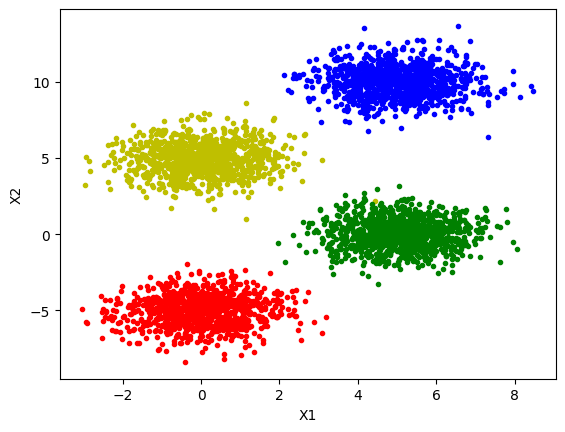

In [157]:
## Defining Mean and Variance for all the data points

dim = 2

mean1 = np.array([0,-5])
mean2 = np.array([0,5])
mean3 = np.array([5,0])
mean4 = np.array([5,10])

mean = [mean1,mean2,mean3,mean4]

var1 = np.diag(np.ones(dim))

var = [var1,var1,var1,var1]
data = GenerateData(1000,mean,var)
print(len(data))
print(data[0][0:5])
print(data[1][0:5])
print(data[2][0:5])
print(data[3][0:5])



plt.figure()
plt.plot(data[0][:,0],data[0][:,1],'.',color='r')
plt.plot(data[1][:,0],data[1][:,1],'.',color='y')
plt.plot(data[2][:,0],data[2][:,1],'.',color='g')
plt.plot(data[3][:,0],data[3][:,1],'.',color='b')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Now the data is augmented to form a single array of data. And a bias term (1) is attached to form a bias term.

In [158]:
## Augmenting Data
data_total = np.array(data).reshape(len(data)*data[0].shape[0],data[0].shape[1])
data_aug=np.concatenate((np.ones((data_total.shape[0],1)),data_total),axis=1)
print(data_aug.shape)

print(data_aug[0:5])
print(data_aug[3000:3005])


(4000, 3)
[[ 1.          0.2411685  -4.27948409]
 [ 1.         -1.22347363 -4.93849031]
 [ 1.          0.60221682 -4.74542151]
 [ 1.          1.02659706 -5.86369651]
 [ 1.         -0.42169455 -6.6620355 ]]
[[ 1.          6.2324035   8.09480555]
 [ 1.          6.04001872  9.0325463 ]
 [ 1.          3.01998562 10.29209751]
 [ 1.          4.14506235 11.58785801]
 [ 1.          6.29175875 10.1896543 ]]


Now the ouput data is formed for all 4000 points where each groups are added to form a single array. This will be serve as the true label.

In [159]:
## Target Labels in Binary Format

y1 = np.tile([-1,-1],(1000,1))
y2 = np.tile([-1,1],(1000,1))
y3 = np.tile([1,-1],(1000,1))
y4 = np.tile([1,1],(1000,1))

y_true = np.concatenate((y1,y2,y3,y4),axis=0)
#print(y1)
#print (len(y_true))
print(len(y_true))
print(y_true[995:1005])

4000
[[-1 -1]
 [-1 -1]
 [-1 -1]
 [-1 -1]
 [-1 -1]
 [-1  1]
 [-1  1]
 [-1  1]
 [-1  1]
 [-1  1]]


For a particular iteration m,
- "data_aug" (a) is of size 4000 * 3 and "w1","w2" is of 3 * 1, so after matric multiplication it becomes 4000 * 1. This is the term for one iteration m 
$s(m) = f(w.T * a(m))$
- e(m) is the error for each iteration. Here error is calculated for each weights w1 and w2. Each of the error is 1 * 4000. So the equation becomes,
$e(m) = b(m) - s(m) $

- So the weight difference at each iteration. Here error is 4000 * 1, error.T is 1 * 4000 and data_aug is 4000 * 3. So multipying them results in 1 * 3. This gives error for bias and the 2 cordinates. The transpose of the result becomes 3 * 1. This is because w1 is of 3*1 and so it will be easy to do operations like addition in the next step. The perceptron learning law equation as gradient descent is
    - $ Δ w = η * e(m) * a(m)$.
Also this calculates the total summation of weight change for all 4000 points. But we need the average change for each iteration, so it is divided by number of samples.

- Now the weight update happens for both cordinates
    - $ w1(m + 1) = w1(m) + Δw1(m)$, and 
    - $ w2(m + 1) = w2(m) + Δw2(m)$

- Here the output activity functions  which outputs (-1, 1)
    - -1 if W.T* a(m) <= 0  
    -  1 if W.T* a(m) > 0

- Now the prediction is done based on the weights.
- After the error is calculated. Here means squared error is considered. The error is used for plotting to understand the conergence. For each iterations the 2 lines comes to make the 4 groups of points separable.
- For plotting the line, 
    - $ z = w1x1 + w2x2 + b $
    The decision boundary is there when z = 0, so w1x1 + w2x2 + b = 0
    or 
    $x2 = - (w1/w2) x1 - (b/w2)$

- The np.linspace() function gives you a set of values across a range to cover the entire plane where your data points might lie, ensuring the line spans across the plot.


[[0.60636871]
 [0.69950338]
 [0.44321952]]
[[0.03227869]
 [0.42409449]
 [0.1134312 ]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


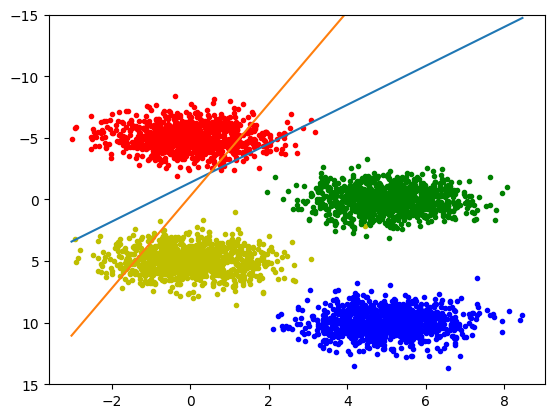

[[0.30159046]
 [0.58598085]
 [0.00689997]]
[[-0.27249956]
 [-0.8232646 ]
 [ 0.78434341]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


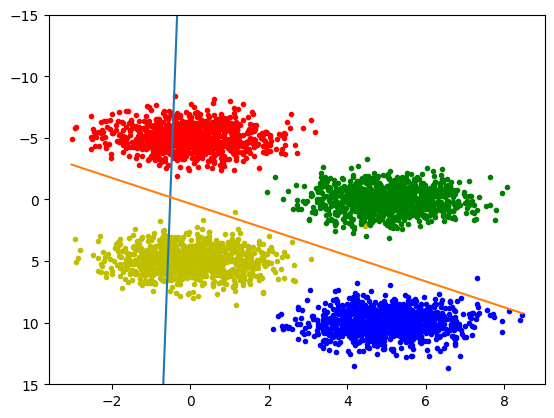

[[0.02471446]
 [0.41114703]
 [0.00442133]]
[[-0.54937556]
 [-2.13193499]
 [ 1.88909655]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


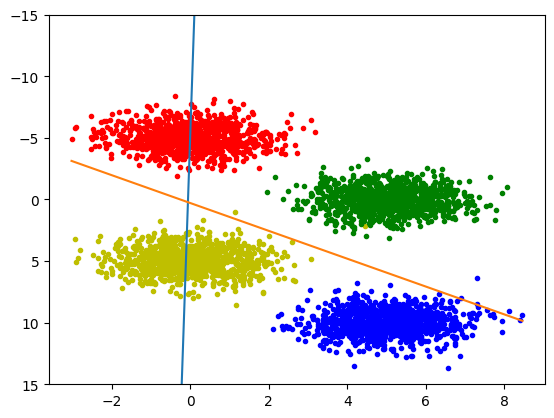

[[-0.15715754]
 [ 0.23688815]
 [ 0.00104442]]
[[-0.73124756]
 [-3.44003043]
 [ 2.9929514 ]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


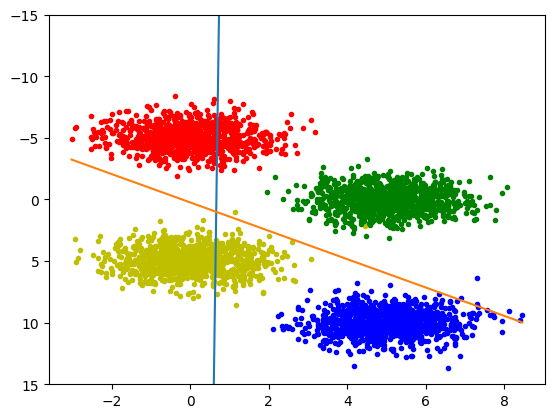

[[-0.22019129]
 [ 0.13892338]
 [-0.00025765]]
[[-0.79428131]
 [-4.67183177]
 [ 4.0988811 ]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


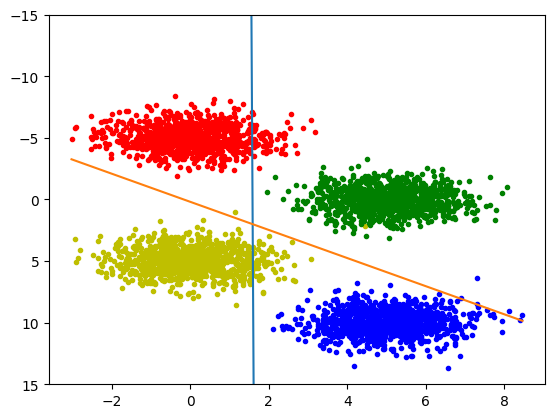

[[-0.23397254]
 [ 0.10775168]
 [ 0.00126461]]
[[-0.80806256]
 [-5.83684003]
 [ 5.20763513]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


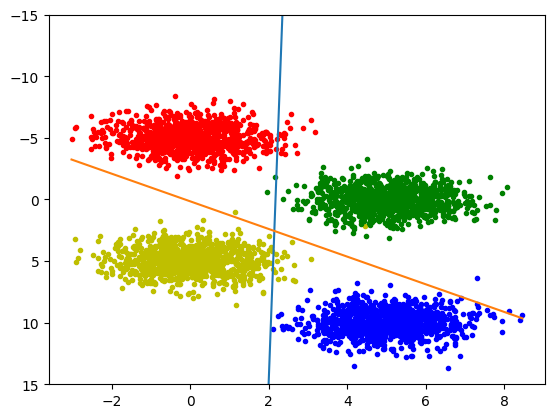

[[-0.23794829]
 [ 0.09661805]
 [ 0.00182124]]
[[-0.81203831]
 [-6.98181023]
 [ 6.31542353]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


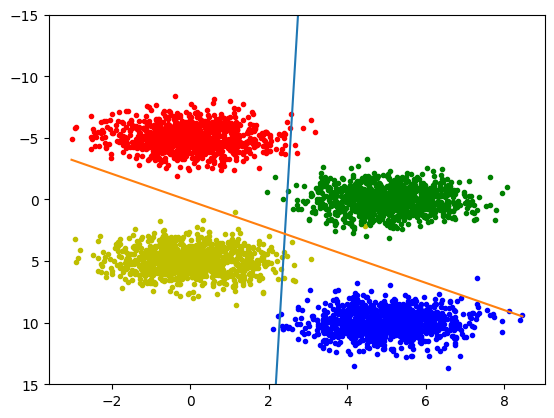

[[-0.23928029]
 [ 0.09180204]
 [ 0.00298647]]
[[-0.81337031]
 [-8.12046281]
 [ 7.42382052]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


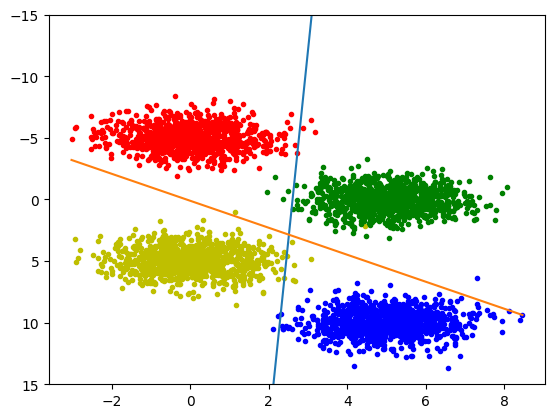

[[-0.23956379]
 [ 0.08974119]
 [ 0.00352923]]
[[-0.81365381]
 [-9.25636022]
 [ 8.53159505]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


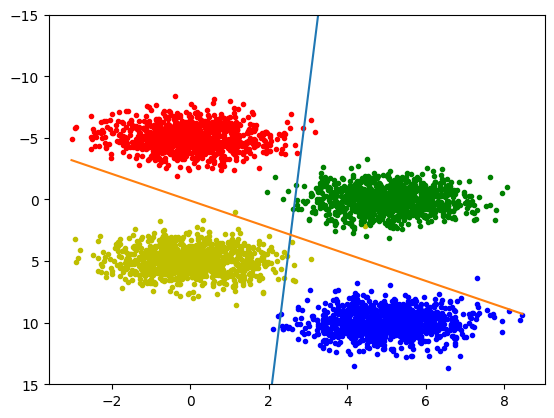

[[-0.23951879]
 [ 0.08856074]
 [ 0.00379676]]
[[ -0.81360881]
 [-10.39137723]
 [  9.63909436]]
Starting value of sequence  -3.032157996209862
Stopping value of sequence  8.46998291135231


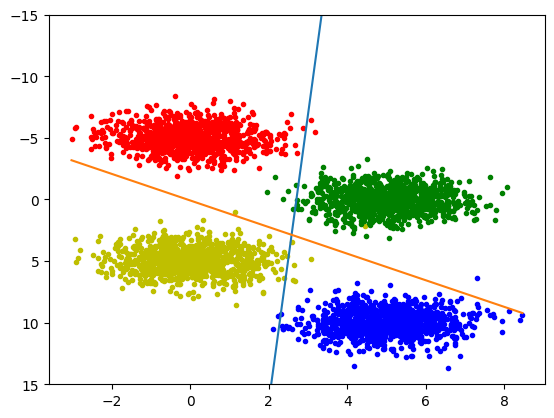

In [160]:
## Percepton Learning Loop

lr = 0.009
w1 = np.random.uniform(-1,1,(data_aug.shape[1],1))
w2 = np.random.uniform(0,1,(data_aug.shape[1],1))
# w1 = np.array([0.2,0.4,0.3]).reshape(3,1)
# w2 = np.array([-0.1,0.3,0.6]).reshape(3,1)
#print(w1)
errors = []

for itr in range(1000):

  # Write your code here
  y_pred1 = np.matmul(data_aug, w1) 
  y_pred2 = np.matmul(data_aug, w2)

  # formatting the prediction in the format of the expected output
  # 2 different Bipolar output function ()
  for index,item in enumerate(y_pred1): 
    if item <= 0: 
      y_pred1[index] = -1
      y_pred2[index] = -1
   
    else:
      y_pred1[index] = 1
      y_pred2[index] = 1

  # Extract the 2 ouputs separately
  y_a = y_true[:, 0][:, np.newaxis]
  y_b = y_true[:, 1][:, np.newaxis]

  # Taking out true values from the 1st column 
  # print (y_a.shape)
  # print (y_b.shape)
  # print(y_a[995:1005])
  # print(y_b[995:1005])
  # break  
  error1 = y_a - y_pred1
  error2 = y_b - y_pred2
  #print(error1.T.shape)
  #print("===============")
  #delta_w1 = lr * np.matmul(error1.T, data_aug)
  #print(delta_w1)
  M = 2 * data_aug.shape[0]
  delta_w1 = (1 / M) * (lr * error1.T @ data_aug).T
  #print("SABY", data_aug.shape[0])
  #print("===============")
  delta_w2 = (1 / M) * (lr * error2.T @ data_aug).T
  
  #delta_w2 = lr * np.matmul(error2.T, data_aug)
  #print(delta_w1) 
  w1 = delta_w1 + w1
  w2 = delta_w2 + w2 

  y_pred = np.concatenate((y_pred1, y_pred2), axis=1)
  mean_squared_error = np.mean((y_true - y_pred) ** 2)

  errors.append(mean_squared_error)

  # 10 plots are made to see the convergence behavior every 100 iterations.
  if(np.remainder(itr, 100) == 0):
    print(w1)
    print(w2)
    print("Starting value of sequence ", np.min(data_aug[:,1]))
    print("Stopping value of sequence ", np.max(data_aug[:,1]))
    # This gives you a set of values across a range to cover the entire plane where your data points might lie, ensuring the line spans across the plot.
    x1 = np.linspace(np.min(data_aug[:,1]), np.max(data_aug[:,1]), 1000)
    x2_1 = (-w1[0] / w1[2])  - ((w1[1] / (w1[2])) * x1)  
    x2_2 = (-w2[0] / w2[2])  - ((w2[1] / (w2[2])) * x1) 
    #print(leq1)
    
    plt.figure()
    plt.plot(data[0][:,0], data[0][:,1], '.', color='r')
    plt.plot(data[1][:,0], data[1][:,1], '.', color='y')
    plt.plot(data[2][:,0], data[2][:,1], '.', color='g')
    plt.plot(data[3][:,0], data[3][:,1], '.', color='b')
    plt.plot(x1, x2_1)
    plt.plot(x1, x2_2)
    plt.ylim((15, -15))
    plt.show()
  


Text(0.5, 1.0, 'Plotting convergence usig Iteration and error')

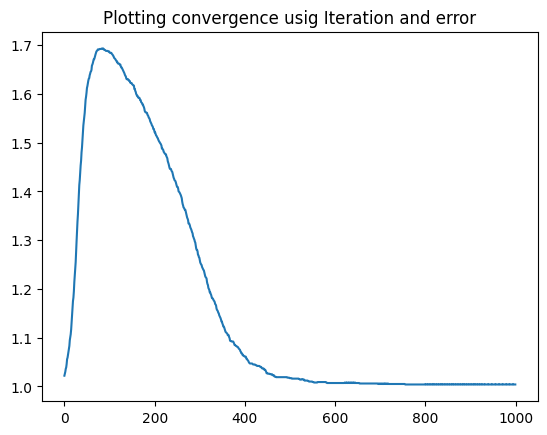

In [161]:
plt.figure()
plt.plot(errors)
plt.title("Plotting convergence usig Iteration and error")

[ 0 -5]
[[1. 0.]
 [0. 1.]]
[0 5]
[[1. 0.]
 [0. 1.]]
[5 0]
[[1. 0.]
 [0. 1.]]
[ 5 10]
[[1. 0.]
 [0. 1.]]
3.0
Testing accuracy Percentage  99.25
Starting value of sequence  -3.2879142649416737
Stopping value of sequence  7.551664307101486


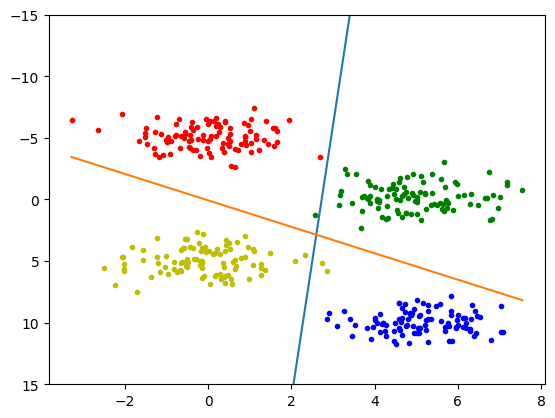

In [162]:
## Testing

dim = 2

mean1 = np.array([0,-5])
mean2 = np.array([0,5])
mean3 = np.array([5,0])
mean4 = np.array([5,10])

mean = [mean1,mean2,mean3,mean4]

var1 = np.diag(np.ones(dim))
var = [var1,var1,var1,var1]

data = GenerateData(100,mean,var)
data_test = np.array(data).reshape(len(data)*data[0].shape[0],data[0].shape[1])

y1 = np.tile([-1,-1],(100,1))
y2 = np.tile([-1,1],(100,1))
y3 = np.tile([1,-1],(100,1))
y4 = np.tile([1,1],(100,1))

y_test = np.concatenate((y1,y2,y3,y4),axis=0)

# Augmentation of data
w = np.concatenate((w1, w2), axis=1)
data_test_aug = np.concatenate((np.ones((data_test.shape[0], 1)), data_test), axis = 1)
y_est = data_test_aug @ w
y_pred = np.ones(y_est.shape)
y_pred[np.where(y_est<0)] = -1
miss = (np.sum(np.abs(y_test - y_pred))) / 2
print(miss)
miss_norm = miss / data_test_aug.shape[0]
accuracy = 100 * (1-miss_norm)

print( "Testing accuracy Percentage ", accuracy)
print("Starting value of sequence ", np.min(data_test_aug[:,1]))
print("Stopping value of sequence ", np.max(data_test_aug[:,1]))
# This gives you a set of values across a range to cover the entire plane where your data points might lie, ensuring the line spans across the plot.
x1 = np.linspace(np.min(data_test_aug[:,1]), np.max(data_test_aug[:,1]), 1000)
x2_1 = (-w1[0] / w1[2])  - ((w1[1] / (w1[2])) * x1)  
x2_2 = (-w2[0] / w2[2])  - ((w2[1] / (w2[2])) * x1) 
#print(leq1)

plt.figure()
plt.plot(data[0][:,0], data[0][:,1], '.', color='r')
plt.plot(data[1][:,0], data[1][:,1], '.', color='y')
plt.plot(data[2][:,0], data[2][:,1], '.', color='g')
plt.plot(data[3][:,0], data[3][:,1], '.', color='b')
plt.plot(x1, x2_1)
plt.plot(x1, x2_2)
plt.ylim((15, -15))
plt.show()
  
  

## Inferences and Conclusion : State all the key observations and conclusion

This experiment shows the convergence of Perceptron learning law using Gradient desent.
- The decision boundaries found during training is during 600 iterations. Here I have kept learning rate as 0.009. 
- The learnt decision boundaries are again used with the data in test set which are new set of 100 date points for each group or 400 data points.
- This is a problem of Perceptron classification problem where Perceptron learning law is being used as Gradient Descent.
- This is in accordance to the Perceptron Convergence theorem that after a large number of steps/iterations, this classification problem was representable because the data is linearly separable. 
